# Precipitation trends in South America
***

**Author**: Chus Casado Rodríguez<br>
**Date**: 15-05-2025<br>

**Introduction**<br>
This notebook analyses the precipitation trends in the GloFAS5 meteorological inputs.

In [1]:
from pathlib import Path
from tqdm.auto import tqdm

import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt

from trend_utils import compute_trend, create_cmap, map_stations

C:\Users\casadje\AppData\Local\Temp\ipykernel_22432\2748460080.py:5: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


## Configuration

In [2]:
LOC = 'South_America'
PATH = Path(f'Z:/nahaUsers/casadje/GloFASv5/stations/{LOC}')

# plots will be saved here
path_plots = PATH / 'catchstats' / 'tp' / 'plots'
path_plots.mkdir(parents=True, exist_ok=True)

## Data
### Stations

240 stations


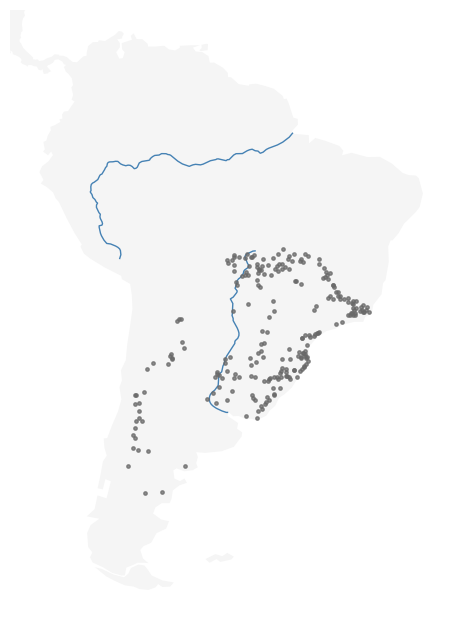

In [3]:
# load
stations = pd.read_excel(PATH / 'SouthAmerica_trends_analysis.xlsx', index_col='EFAS_id')
stations = gpd.GeoDataFrame(
    data=stations,
    geometry=gpd.points_from_xy(stations.Xlisflood, stations.Ylisflood),
    crs='epsg:4326'
)

print(f'{len(stations)} stations')

# plot
map_stations(stations, extent=[-85, -30, -60, 15])

### Time series

In [4]:
# load
precipitation = xr.open_mfdataset((PATH / 'catchstats' / 'tp').glob('*.nc'))['tp_mean'].compute()
precipitation['time'] = precipitation['time'] - pd.Timedelta(days=1)

print('Time series:\n\t{0} days\n\t{1} stations'.format(*precipitation.shape))

Time series:
	17897 days
	240 stations


## Analysis

### Compute trends

In [5]:
# compute total annual precipitation
precip_yr = precipitation.groupby(precipitation.time.dt.year).sum().to_pandas()

# compute average annual precipitation
stations['precip_mm'] = precip_yr.mean()

# compute trends: all period, 80s-2000s, 90s-10s, 2000s-20s
trends = compute_trend(precip_yr).transpose()
trends_8000 = compute_trend(precip_yr.loc['1980-01-02':'2000-01-01']).transpose()
trends_9010 = compute_trend(precip_yr.loc['1990-01-02':'2010-01-01']).transpose()
trends_0020 = compute_trend(precip_yr.loc['2000-01-02':'2020-01-01']).transpose()

In [6]:
# plot time series of annual precipitation
for ID in precip_yr.columns:
    fig, ax = plt.subplots(figsize=(16, 3))
    ax.plot(precip_yr[ID], zorder=10, label='ERA5')
    
    intercept, slope, pvalue = trends.loc[ID, ['intercept', 'slope', 'pval']]
    ax.plot(precip_yr.index, intercept + precip_yr.index * slope, c='k', ls='--', lw=.8, zorder=0, label='trend complete')
    # ax.text(0.01, 0.05, f'trend = {slope:.1f} mm/yr\np-value = {pvalue:.4f}', transform=ax.transAxes)
    
    idx = pd.date_range('1980-01-02', '2000-01-01', freq='YS').year
    intercept, slope, pvalue = trends_8000.loc[ID, ['intercept', 'slope', 'pval']]
    ax.plot(idx, intercept + idx * slope, ls=':', lw=.8, zorder=1, label='trend 80s-90s')
    
    idx = pd.date_range('1990-01-02', '2010-01-01', freq='YS').year
    intercept, slope, pvalue = trends_9010.loc[ID, ['intercept', 'slope', 'pval']]
    ax.plot(idx, intercept + idx * slope, ls=':', lw=.8, zorder=2, label='trend 90s-00s')
    
    idx = pd.date_range('2000-01-02', '2020-01-01', freq='YS').year
    intercept, slope, pvalue = trends_0020.loc[ID, ['intercept', 'slope', 'pval']]
    ax.plot(idx, intercept + idx * slope, ls=':', lw=.8, zorder=3, label='trend 00s-10s')
    
    ax.legend(frameon=False, loc=4)
    ax.set(
        xlim=(precip_yr.first_valid_index(), precip_yr.last_valid_index()),
        ylabel='annual precipitation (mm)',
        ylim=(0, None),
        title=ID
    );
    jpg_file = path_plots / f'{ID}.jpg'
    plt.savefig(jpg_file, dpi=300, bbox_inches='tight')
    print(f'Plot saved in {jpg_file}', end='\r')
    plt.close()
print('\n')

Saved file Z:\nahaUsers\casadje\GloFASv5\stations\South_America\catchstats\tp\plots\15678.jpg



### Export shapefile

In [7]:
# add trends to `stations`
trends_8000.columns = [f'{col}_8000' for col in trends_8000.columns]
trends_9010.columns = [f'{col}_9010' for col in trends_9010.columns]
trends_0020.columns = [f'{col}_0020' for col in trends_0020.columns]
stations = pd.concat((
    stations, 
    trends[['slope', 'pval']],
    trends_8000[['slope_8000', 'pval_8000']],
    trends_9010[['slope_9010', 'pval_9010']],
    trends_0020[['slope_0020', 'pval_0020']],
    ),
    axis=1
)

# convert "slope" to % change in precipitation per decade
stations.slope = stations.slope / stations.precip_mm * 1000
stations.slope_8000 = stations.slope_8000 / precip_yr.loc['1980-01-02':'2000-01-01'].mean() * 1000
stations.slope_9010 = stations.slope_9010 / precip_yr.loc['1990-01-02':'2010-01-01'].mean() * 1000
stations.slope_0020 = stations.slope_0020 / precip_yr.loc['2000-01-02':'2020-01-01'].mean() * 1000

# export shapefile
stations.index.name = 'EFAS_ID'
stations.drop('wkt_geom', axis=1, inplace=True, errors='ignore')
shp_file = PATH / f'{LOC.lower()}_precip_trends.shp'
stations.reset_index().to_file(shp_file)
print(f'Shapefile saved in {shp_file}')

Shapefile saved in Z:\nahaUsers\casadje\GloFASv5\stations\South_America\south_america_precip_trends.shp


### Plots

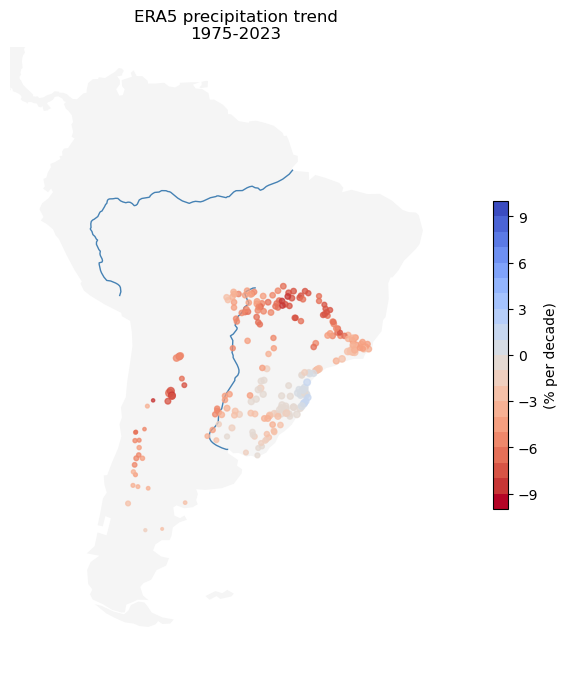

In [8]:
map_stations(
    stations,
    s=stations.precip_mm / 100, 
    c=stations.slope, 
    extent=[-85, -30, -60, 15],
    title='ERA5 precipitation trend\n1975-2023',
    label='(% per decade)'
)

Plot saved in Z:\nahaUsers\casadje\GloFASv5\stations\South_America\catchstats\tp\plots\trends_per_decade.jpg


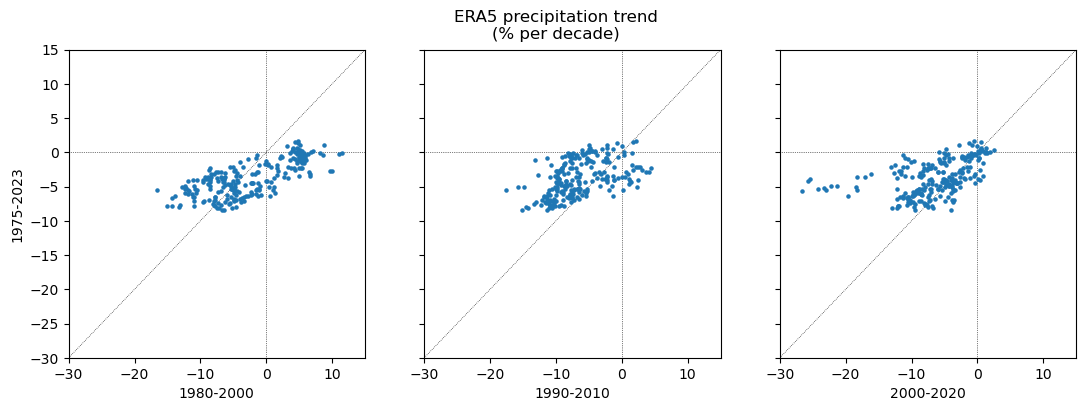

In [9]:
fig, axes = plt.subplots(ncols=3, figsize=(13, 4), sharex=True, sharey=True)
vlim = (-30, 15)
for ax, col, label in zip(axes, ['slope_8000', 'slope_9010', 'slope_0020'], ['1980-2000', '1990-2010', '2000-2020']):
    ax.scatter(stations[col], stations.slope, s=5)
    ax.set(
        xlim=vlim,
        ylim=vlim,
        xlabel=label,
    )
    if ax == axes[0]:
        ax.set_ylabel('1975-2023')
    ax.plot([vlim[0], vlim[1]], [vlim[0], vlim[1]], c='k', ls=':', lw=.5, zorder=0)
    ax.axhline(0, c='k', ls=':', lw=.5, zorder=0)
    ax.axvline(0, c='k', ls=':', lw=.5, zorder=0);
fig.suptitle('ERA5 precipitation trend\n(% per decade)');
jpg_file = path_plots / f'trends_per_decade.jpg'
plt.savefig(jpg_file, dpi=300, bbox_inches='tight')
print(f'Plot saved in {jpg_file}')